## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# EVA 2

# Librerías

In [88]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate, lambdify, exp
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame, cross, Point, dot
from numpy import deg2rad, linspace, gradient
import numpy as np
import matplotlib.pyplot as plt
init_vprinting(use_latex='mathjax')
import scipy as sp
from scipy.integrate import solve_ivp

## ej1

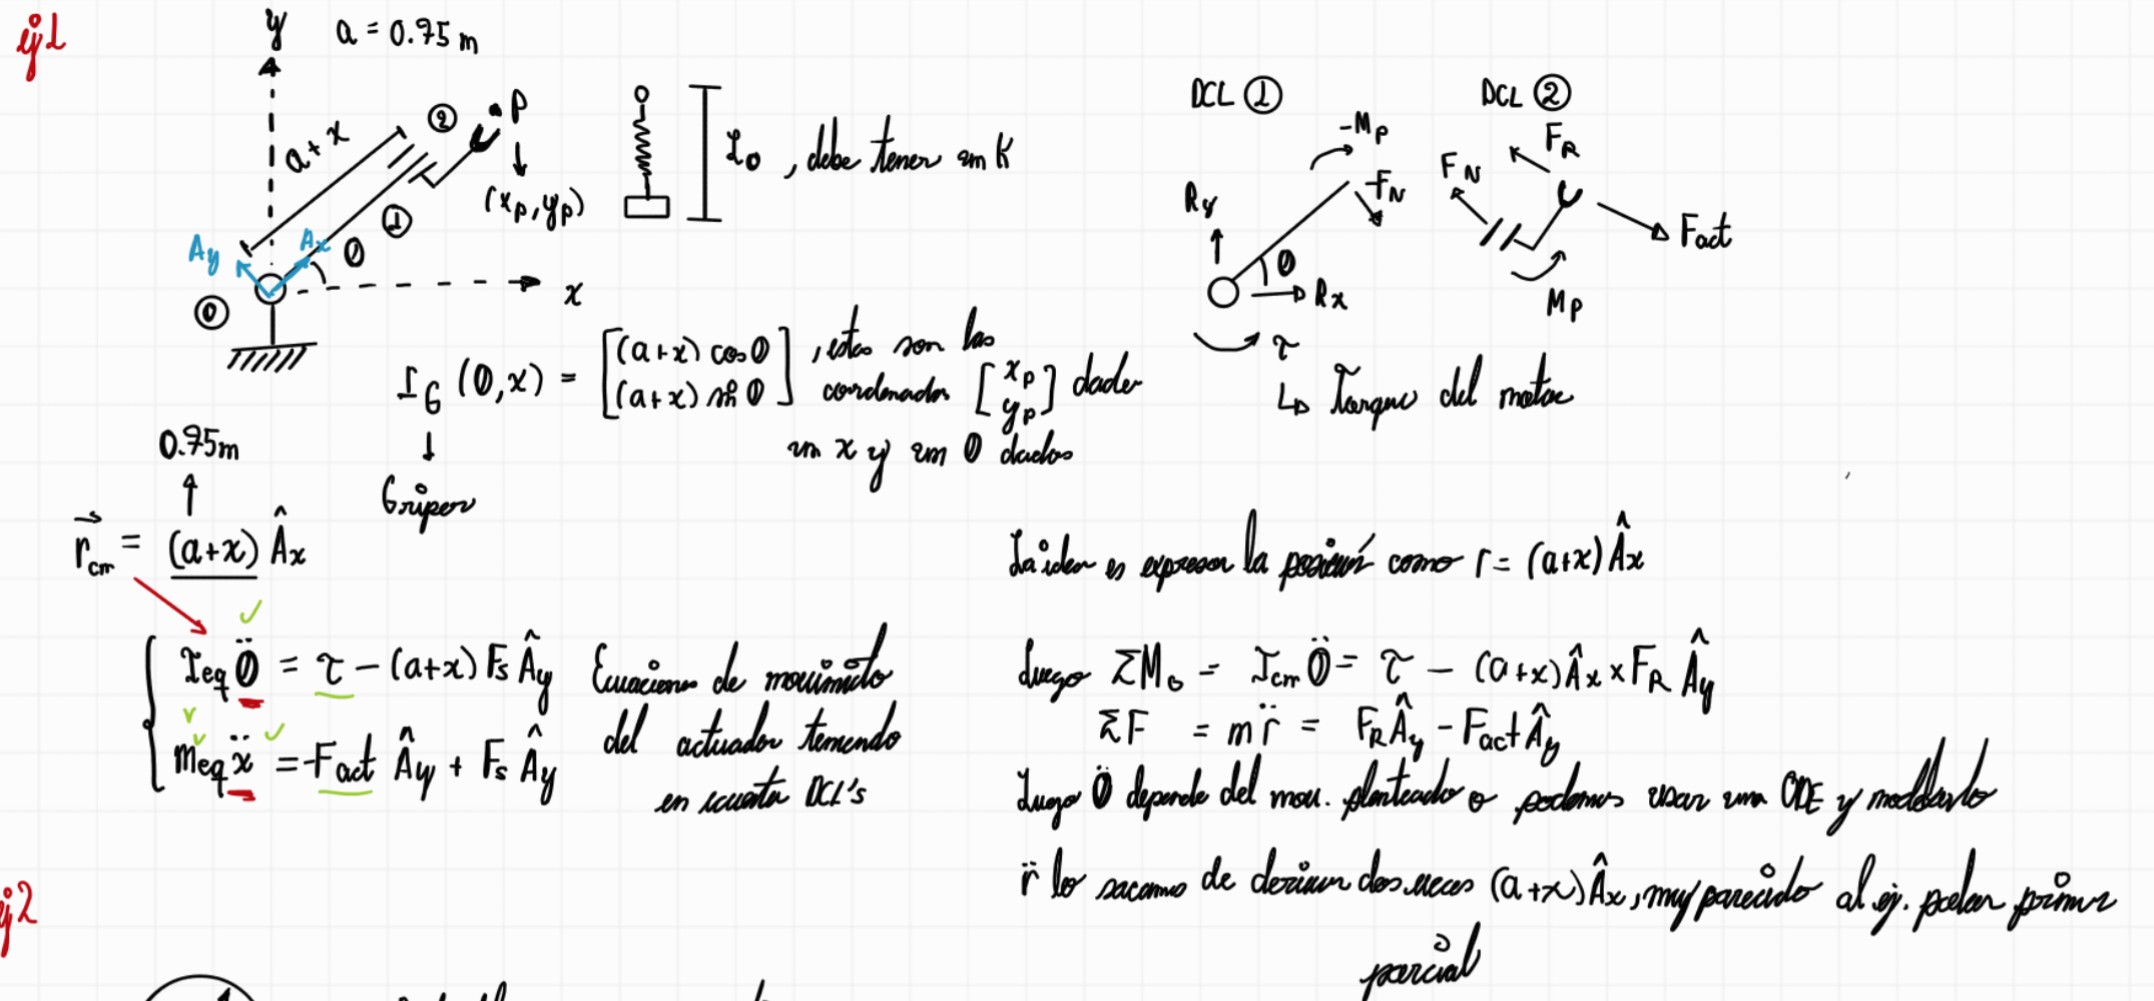

=== RESULTADOS EN LA POSICIÓN FINAL Q = [0.8, 1.3] ===
Ángulo final (theta) = 58.39°
Longitud final (x) = 1.526 m
Torque del motor (τθ) = 0.10 N·m
Fuerza del actuador (F_act) = 1539.65 N


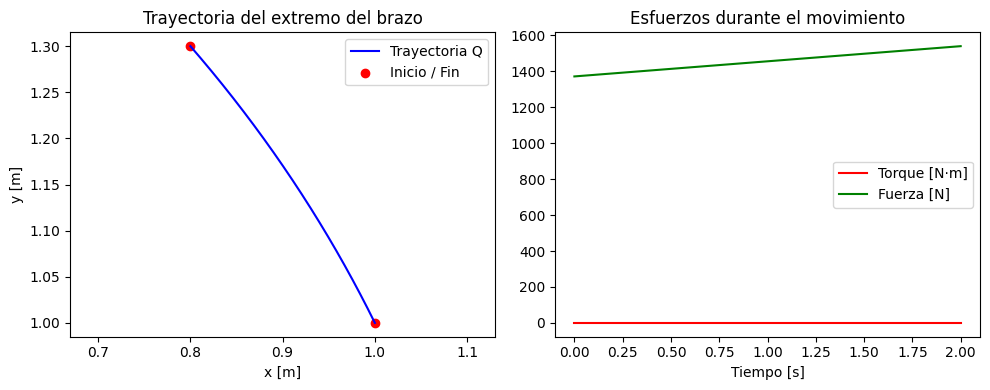

In [89]:

t = symbols('t', real=True)
theta = dynamicsymbols('theta')  # Ángulo del brazo 
x = dynamicsymbols('x')          # Longitud del brazo (prismática)

# Parámetros físicos
m = 5.0        # masa [kg]
L0 = 0.5       # longitud natural del resorte [m]
k = 1500.0     # constante elástica [N/m]
I = 0.2        # inercia rotacional [kg*m^2]
g = 9.81

# Posiciones del anclaje P y del extremo Q
Px, Py = 0, 0
Qx = x * cos(theta)
Qy = x * sin(theta)

# Longitud del resorte
L = sqrt((Qx - Px)**2 + (Qy - Py)**2)

# Magnitud de la fuerza del resorte
F_spring = k * (L - L0) # Ecuación de fuerza del resorte


Fx = -F_spring * (Qx - Px) / L # Fuerza del resote por componentes
Fy = -F_spring * (Qy - Py) / L # Fuerza del resorte por componentes

# Torque en el motor de la articulación (revoluta)

tau_theta = ( # Diagrama de cuerpo libre 1
    I * diff(theta, t, 2)
    + m * (x**2) * diff(theta, t, 2)
    + 2 * m * x * diff(x, t) * diff(theta, t)
    + x * Fy * cos(theta)
    - x * Fx * sin(theta)
)

# Fuerza del actuador lineal (prismática) 
# Este del diagrama de cuerpo libre 2
F_act = m * diff(x, t, 2) - Fx * cos(theta) - Fy * sin(theta)


# Punto inicial y final deseado
P_ini = np.array([1.0, 1.0])
Q_fin = np.array([0.8, 1.3])

# Longitud y ángulo inicial
x_ini = np.linalg.norm(P_ini)
theta_ini = np.arctan2(P_ini[1], P_ini[0])

# Longitud y ángulo final
x_fin = np.linalg.norm(Q_fin)
theta_fin = np.arctan2(Q_fin[1], Q_fin[0])

# Trayectorias planificadas (lineales)
t_vals = np.linspace(0, 2, 200)
theta_vals = np.linspace(theta_ini, theta_fin, len(t_vals))
x_vals = np.linspace(x_ini, x_fin, len(t_vals))

# Derivadas numéricas
dtheta = np.gradient(theta_vals, t_vals)
ddtheta = np.gradient(dtheta, t_vals)
dx = np.gradient(x_vals, t_vals)
ddx = np.gradient(dx, t_vals)

tau_list = []
F_list = []

for i in range(len(t_vals)):
    th, xd = theta_vals[i], x_vals[i]
    dth, ddth = dtheta[i], ddtheta[i]
    dx_i, ddx_i = dx[i], ddx[i]

    # Fuerzas del resorte
    Fx_i = -k * ((xd - L0)) * np.cos(th)
    Fy_i = -k * ((xd - L0)) * np.sin(th)

    # Torque y fuerza
    tau_i = I * ddth + m * (xd**2) * ddth + 2*m*xd*dx_i*dth \
            + xd*Fy_i*np.cos(th) - xd*Fx_i*np.sin(th)
    F_i = m*ddx_i - Fx_i*np.cos(th) - Fy_i*np.sin(th)

    tau_list.append(tau_i)
    F_list.append(F_i)

# Resultados finales (posición Q_final)

tau_final = tau_list[-1]
F_final = F_list[-1]

print("=== RESULTADOS EN LA POSICIÓN FINAL Q = [0.8, 1.3] ===")
print(f"Ángulo final (theta) = {np.degrees(theta_fin):.2f}°")
print(f"Longitud final (x) = {x_fin:.3f} m")
print(f"Torque del motor (τθ) = {tau_final:.2f} N·m")
print(f"Fuerza del actuador (F_act) = {F_final:.2f} N")

# Gráficas de la trayectoria y esfuerzos

qx_vals = x_vals * np.cos(theta_vals)
qy_vals = x_vals * np.sin(theta_vals)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(qx_vals, qy_vals, 'b', label='Trayectoria Q')
plt.scatter([qx_vals[0], qx_vals[-1]], [qy_vals[0], qy_vals[-1]], color='r', label='Inicio / Fin')
plt.title("Trayectoria del extremo del brazo")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis('equal')
plt.legend()

plt.subplot(1,2,2)
plt.plot(t_vals, tau_list, 'r', label='Torque [N·m]')
plt.plot(t_vals, F_list, 'g', label='Fuerza [N]')
plt.title("Esfuerzos durante el movimiento")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.tight_layout()
plt.show()


## ej1 bono

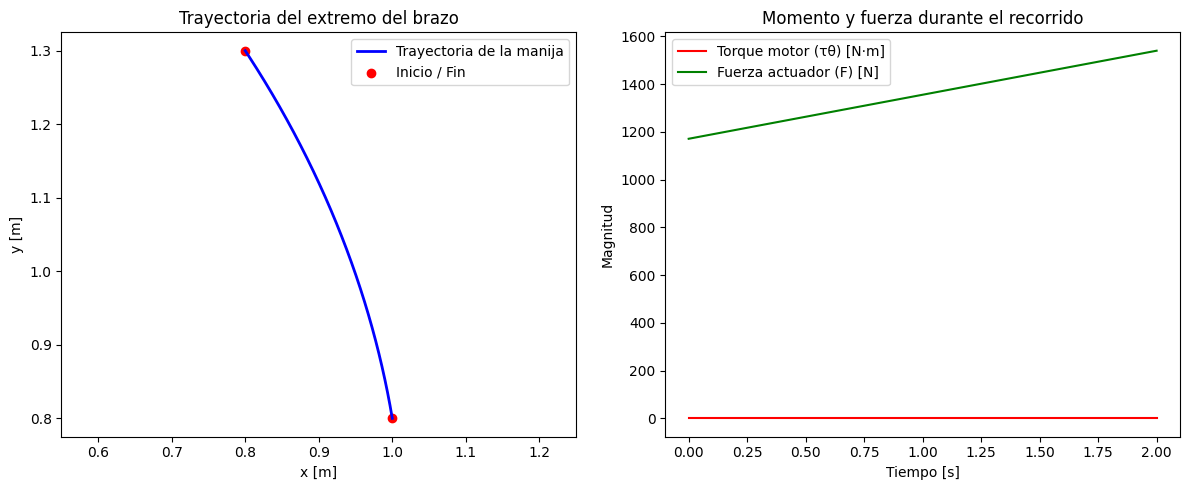

=== RESULTADOS FINALES EN Q = [0.8, 1.3] ===
Ángulo final θ = 58.39°
Longitud final x = 1.526 m
Torque final τθ = 0.32 N·m
Fuerza final F = 1539.65 N


In [90]:
t = symbols('t', real=True)
theta = dynamicsymbols('theta')
x = dynamicsymbols('x')
m = 5.0        
I = 0.2        
k = 1500.0     
L0 = 0.5       

P_ini = np.array([1.0, 0.8])
Q_fin = np.array([0.8, 1.3])

x_ini = np.linalg.norm(P_ini)
x_fin = np.linalg.norm(Q_fin)
theta_ini = np.arctan2(P_ini[1], P_ini[0])
theta_fin = np.arctan2(Q_fin[1], Q_fin[0])

# Trayectorias y derivadas
t_vals = np.linspace(0, 2, 200)
theta_vals = np.linspace(theta_ini, theta_fin, len(t_vals))
x_vals = np.linspace(x_ini, x_fin, len(t_vals))
dtheta = np.gradient(theta_vals, t_vals)
ddtheta = np.gradient(dtheta, t_vals)
dx = np.gradient(x_vals, t_vals)
ddx = np.gradient(dx, t_vals)

# Cálculo del torque y la fuerza en cada instante
tau_list, F_list = [], []

for i in range(len(t_vals)):
    th, xd = theta_vals[i], x_vals[i]
    dth, ddth = dtheta[i], ddtheta[i]
    dx_i, ddx_i = dx[i], ddx[i]
    
    # Fuerzas del resorte
    Fx_i = -k * ((xd - L0)) * np.cos(th)
    Fy_i = -k * ((xd - L0)) * np.sin(th)

    # Torque en el motor (rotacional)
    tau_i = I * ddth + m * (xd**2) * ddth + 2*m*xd*dx_i*dth \
            + xd*Fy_i*np.cos(th) - xd*Fx_i*np.sin(th)
    
    # Fuerza en el actuador lineal
    F_i = m*ddx_i - Fx_i*np.cos(th) - Fy_i*np.sin(th)

    tau_list.append(tau_i)
    F_list.append(F_i)

# Graficar resultados (Aquí si uso intensivo de ChatGPT para graficar de forma correcta)

qx_vals = x_vals * np.cos(theta_vals)
qy_vals = x_vals * np.sin(theta_vals)

plt.figure(figsize=(12,5))

# --- Subplot 1: Trayectoria ---
plt.subplot(1,2,1)
plt.plot(qx_vals, qy_vals, 'b', linewidth=2, label='Trayectoria de la manija')
plt.scatter([qx_vals[0], qx_vals[-1]], [qy_vals[0], qy_vals[-1]], c='r', label='Inicio / Fin')
plt.title("Trayectoria del extremo del brazo")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis('equal')
plt.legend()

# --- Subplot 2: Torque y fuerza ---
plt.subplot(1,2,2)
plt.plot(t_vals, tau_list, 'r', label='Torque motor (τθ) [N·m]')
plt.plot(t_vals, F_list, 'g', label='Fuerza actuador (F) [N]')
plt.title("Momento y fuerza durante el recorrido")
plt.xlabel("Tiempo [s]")
plt.ylabel("Magnitud")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 6) Mostrar valores finales
# --------------------------------------------------------------
print("=== RESULTADOS FINALES EN Q = [0.8, 1.3] ===")
print(f"Ángulo final θ = {np.degrees(theta_fin):.2f}°")
print(f"Longitud final x = {x_fin:.3f} m")
print(f"Torque final τθ = {tau_list[-1]:.2f} N·m")
print(f"Fuerza final F = {F_list[-1]:.2f} N")


### Análisis de resultados

Note que en el segundo caso, el del bono, la fuerza final va a aser mucho mayor que la fuerza final del anterior ejemplo, esto pues a la diferencia entre las posiciones es mayor, por lo que vemos que la fuerza que tiene que hacer el actuador para contrarestar la fuerza del resorte va a terminar siendo mayor. Esto es consistente con la forma en la que se plantearon las ecuaciones puesto auqe vemos que la longitud del resorte va a ser directamente proporcional al vector de diferencia de posición entre la posición inicial y la posición final.

## ej2

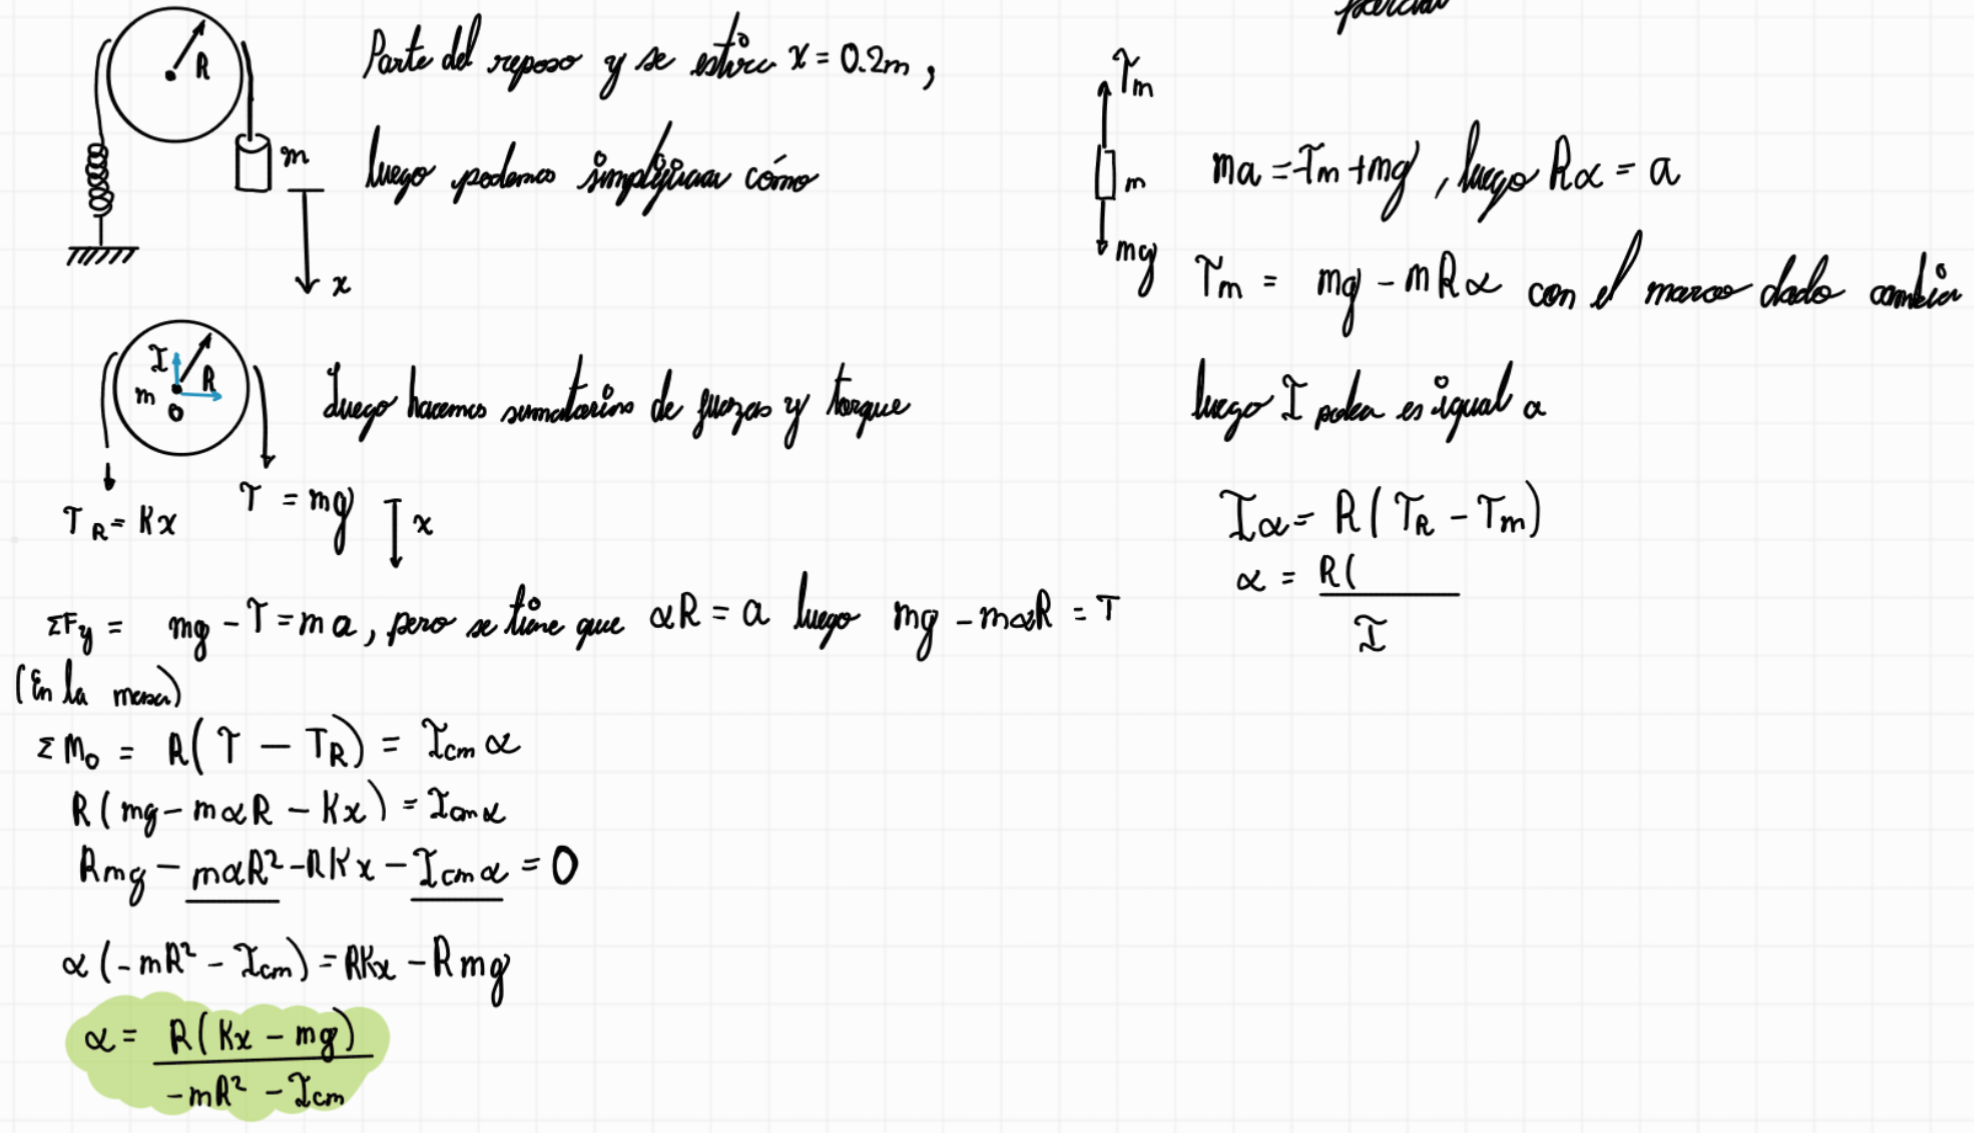

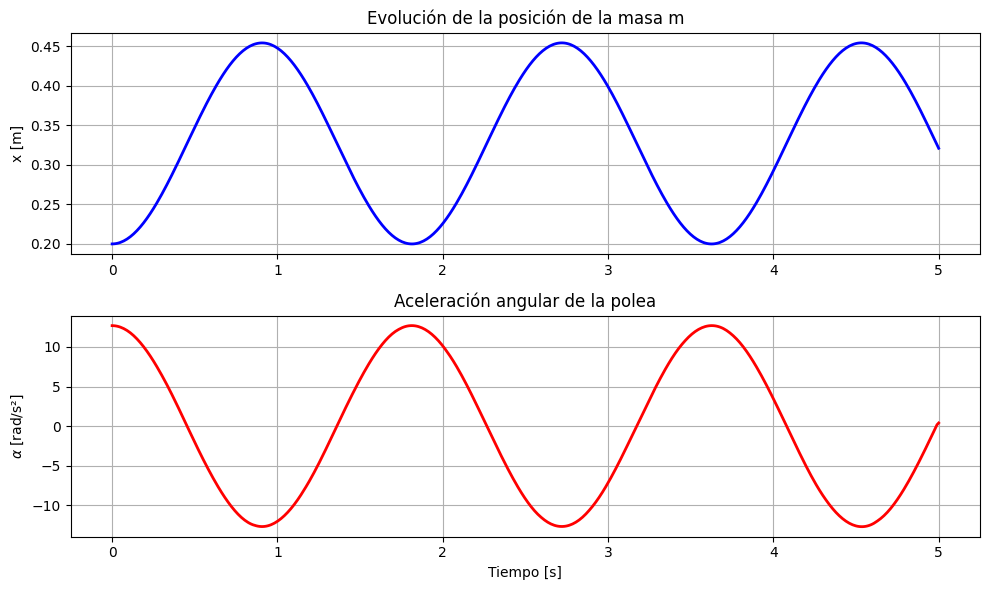

Aceleración angular inicial: α₀ = 12.70 rad/s²


In [91]:
# Parámetros físicos
m_p = 1.5      # kg
m = 0.5        # kg
k = 15         # N/m
R = 0.12       # m
g = 9.81       # m/s^2

# Inercia de la polea
I = 0.5 * m_p * R**2

# Ecuación de movimiento: d²x/dt² = (mg - kx) / (m + I/R²)
def dynamics(t, y):
    x, x_dot = y
    x_ddot = (m*g - k*x) / (m + I/R**2)
    return [x_dot, x_ddot]

# Condiciones iniciales
x0 = 0.20     # m (estiramiento inicial)
v0 = 0.0      # m/s
y0 = [x0, v0]

# Tiempo de simulación
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

# Resolver ODE
sol = solve_ivp(dynamics, t_span, y0, t_eval=t_eval)

x = sol.y[0]
x_dot = sol.y[1]
alpha = np.gradient(x_dot, t_eval) / R  # aceleración angular
theta = np.cumsum(alpha) * (t_eval[1]-t_eval[0])  # integración simple

# ----------------- GRAFICAR -----------------
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t_eval, x, 'b', lw=2)
plt.title("Evolución de la posición de la masa m")
plt.ylabel("x [m]")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t_eval, alpha, 'r', lw=2)
plt.title("Aceleración angular de la polea")
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$\alpha$ [rad/s²]")
plt.grid(True)

plt.tight_layout()
plt.show()

# Valor de aceleración angular inicial
alpha_0 = (R*(m*g - k*x0)) / (I + m*R**2)
print(f"Aceleración angular inicial: α₀ = {alpha_0:.2f} rad/s²")


## ej2 bono

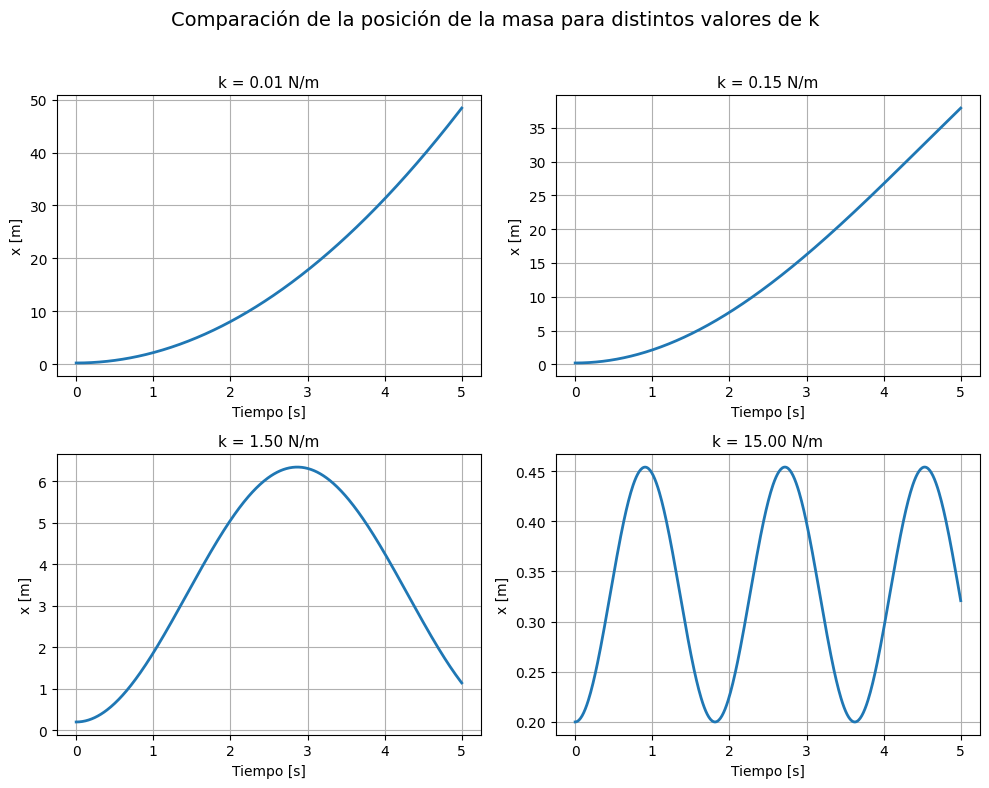

In [92]:
# Parámetros base
m_p = 1.5   # kg
m = 0.5     # kg
R = 0.12    # m
g = 9.81    # m/s^2
I = 0.5 * m_p * R**2

# Condiciones iniciales
x0 = 0.20
v0 = 0.0
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

# Valores de rigidez del resorte
k_values = [0.01, 0.15, 1.5, 15]

fig, axs = plt.subplots(2, 2, figsize=(10,8))
axs = axs.flatten()

for i, k in enumerate(k_values):
    # Definir dinámica para cada k
    def dynamics(t, y):
        x, x_dot = y
        x_ddot = (m*g - k*x) / (m + I/R**2)
        return [x_dot, x_ddot]

    sol = solve_ivp(dynamics, t_span, [x0, v0], t_eval=t_eval)
    x = sol.y[0]

    axs[i].plot(t_eval, x, lw=2)
    axs[i].set_title(f"k = {k:.2f} N/m", fontsize=11)
    axs[i].set_xlabel("Tiempo [s]")
    axs[i].set_ylabel("x [m]")
    axs[i].grid(True)

plt.suptitle("Comparación de la posición de la masa para distintos valores de k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Análisis de resultados

Al comparar los cuatro casos, se observa que el comportamiento del sistema depende fuertemente de la rigidez del resorte (k). Para valores pequeños 0.01 N/m y 0.15 N/m, el resorte ofrece poca oposición, por lo que la masa se desplaza principalmente por efecto de la gravedad y la posición aumenta de forma casi parabólica.

Con un valor intermedio (k = 1.5N/m), el resorte comienza a equilibrar la acción del peso y el sistema presenta oscilaciones amplias alrededor de la posición de equilibrio, propias de un régimen subamortiguado.

Finalmente, para un resorte rígido (k = 15 N/m), las oscilaciones son de pequeña amplitud y alta frecuencia, indicando un sistema con respuesta más controlada y estable. En general, a medida que (k) aumenta, el sistema se vuelve más rígido, con movimientos más rápidos y de menor desplazamiento.

## ej3

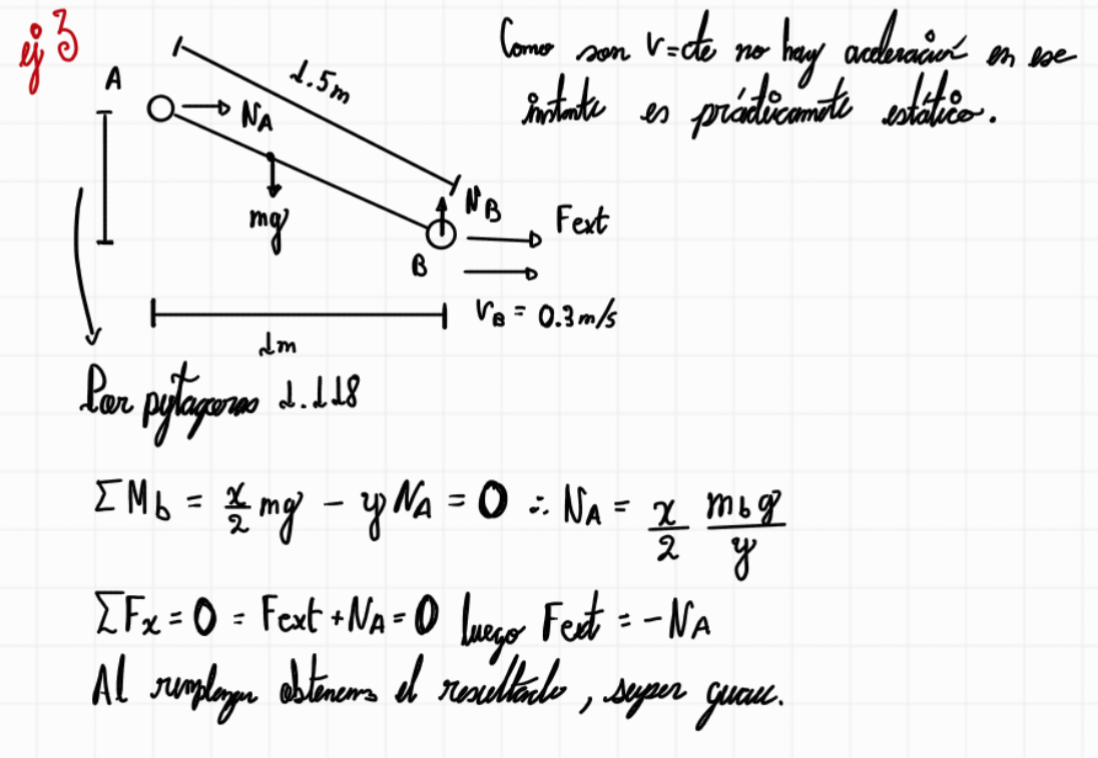

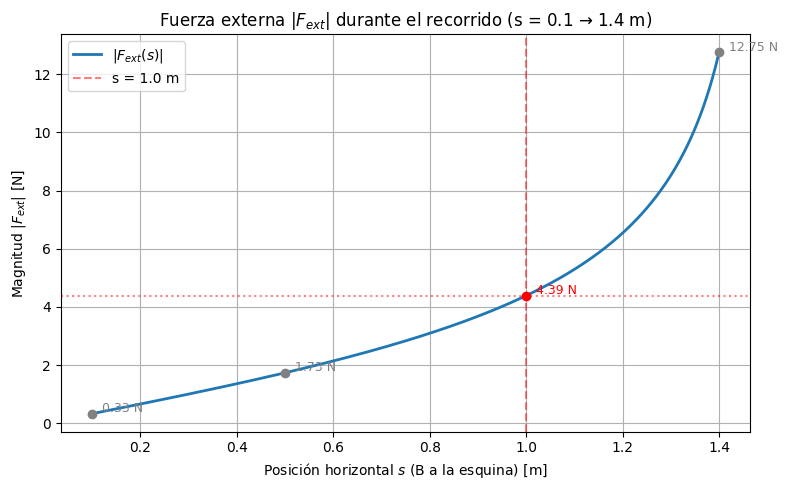

  Rango analizado: s ∈ [0.10, 1.40] m
  F_ext mínimo ≈ 0.33 N  (s ≈ 0.10 m)
  F_ext máximo ≈ 12.75 N  (s ≈ 1.40 m)
  Punto de referencia (s = 1.0 m): F_ext ≈ 4.39 N  coincide con el valor teórico del parcial  a mano


In [93]:
# Parámetros del sistema
L = 1.50        # longitud de la barra [m]
m_b = 1.0       # masa de la barra [kg]
g = 9.81        # gravedad [m/s^2]

# Recorrido horizontal del rodillo B
s_min = 0.1
s_max = 1.4
s_vals = np.linspace(s_min, s_max, 400)

# Calculos geométricos
y_vals = np.sqrt(np.maximum(0.0, L**2 - s_vals**2))
N_A_vals = (s_vals / 2.0) * (m_b * g) / y_vals # Esto calculando a mano la expresión de F_ext
F_ext_vals = -N_A_vals
F_ext_mag = np.abs(F_ext_vals)

plt.figure(figsize=(8,5))
plt.plot(s_vals, F_ext_mag, lw=2, label=r'$|F_{ext}(s)|$')

# Puntos de interés estándar
for s_annot in [0.1, 0.5, 1.0, 1.4]:
    y_a = np.sqrt(L**2 - s_annot**2)
    F_a = abs((s_annot/2.0)*(m_b*g)/y_a)
    color = 'red' if s_annot == 1.0 else 'gray'
    plt.scatter(s_annot, F_a, color=color, zorder=5)
    plt.text(s_annot + 0.02, F_a + 0.05, f"{F_a:.2f} N", fontsize=9, color=color)

# Destacar el punto s=1.0 m (valor del parcial)
s_ref = 1.0
y_ref = np.sqrt(L**2 - s_ref**2)
F_ref = abs((s_ref / 2.0) * (m_b * g) / y_ref)
plt.axvline(s_ref, color='red', linestyle='--', alpha=0.5, label=f"s = {s_ref} m")
plt.axhline(F_ref, color='red', linestyle=':', alpha=0.5)

# Etiquetas y formato (Yo no sabía que esto se podía, pero ChatGPT lo metio y lo dejo porque me parece chevre el formato)
plt.xlabel("Posición horizontal $s$ (B a la esquina) [m]")
plt.ylabel(r"Magnitud $|F_{ext}|$ [N]")
plt.title("Fuerza externa $|F_{ext}|$ durante el recorrido (s = 0.1 → 1.4 m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Mostrar resumen numérico
# --------------------------------------------------------------
print(f"  Rango analizado: s ∈ [{s_min:.2f}, {s_max:.2f}] m")
print(f"  F_ext mínimo ≈ {F_ext_mag.min():.2f} N  (s ≈ {s_vals[F_ext_mag.argmin()]:.2f} m)")
print(f"  F_ext máximo ≈ {F_ext_mag.max():.2f} N  (s ≈ {s_vals[F_ext_mag.argmax()]:.2f} m)")
print(f"  Punto de referencia (s = {s_ref} m): F_ext ≈ {F_ref:.2f} N  coincide con el valor teórico del parcial  a mano")


## ej 3 bono

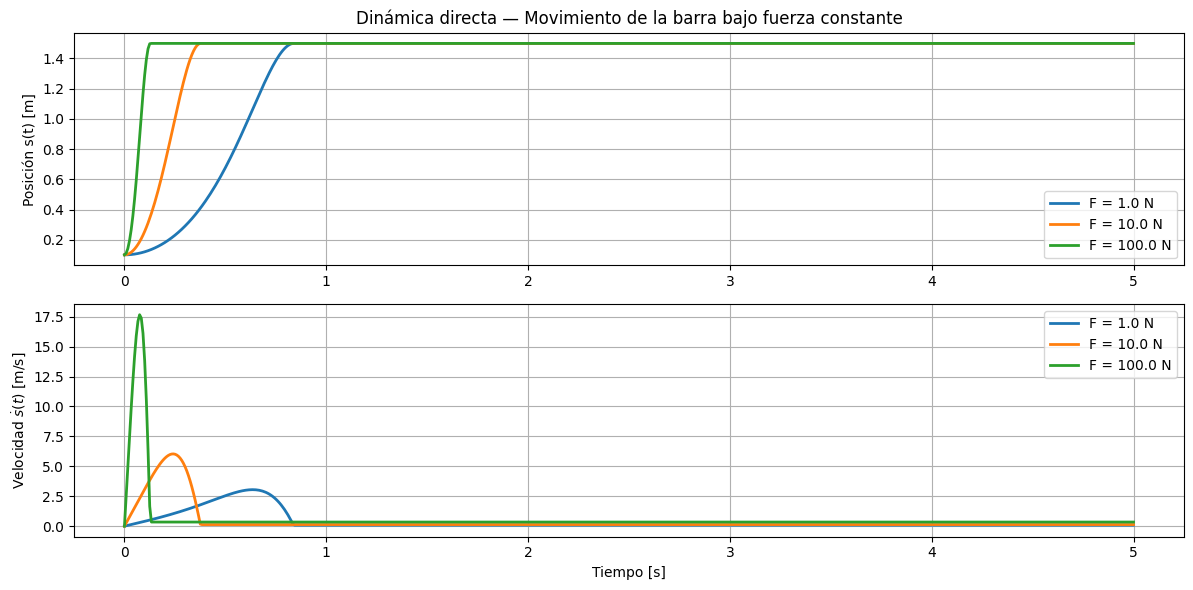

F =    1.0 N  →  s(5s) = 1.4999 m   |   s_dot(5s) = 0.0832 m/s
F =   10.0 N  →  s(5s) = 1.4999 m   |   s_dot(5s) = 0.1304 m/s
F =  100.0 N  →  s(5s) = 1.4999 m   |   s_dot(5s) = 0.3431 m/s


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parámetros físicos ---
L = 1.50       # longitud de la barra [m]
m_b = 1.0      # masa de la barra [kg]
g = 9.81       # gravedad [m/s^2]
I_cm = (1/12) * m_b * L**2  # inercia barra delgada en el centro
C = I_cm + m_b * (L**2) / 4 # término efectivo de inercia

# --- Condiciones iniciales ---
s0 = 0.1       # posición inicial [m]
sdot0 = 0.0    # velocidad inicial [m/s]

# --- Tiempo de simulación ---
t_span = (0, 5)
t_eval = np.linspace(t_span[0], t_span[1], 600)

# --- Fuerzas externas a probar ---
F_list = [1.0, 10.0, 100.0]  # [N]

# --- Función auxiliar para aceleración ---
def s_ddot(s, s_dot, F_ext):
    # Evitar raíces negativas o divisiones por cero
    s = np.clip(s, -L + 1e-4, L - 1e-4)
    y = np.sqrt(L**2 - s**2)
    A = C / (y**2)
    A_prime = 2 * C * s / (L**2 - s**2)**2
    # Ecuación: A*s¨ + 0.5*A' s˙² - m*g*s/(2y) = F_ext
    s_dd = (F_ext + (m_b * g * s) / (2 * y) - 0.5 * A_prime * s_dot**2) / A
    return s_dd

# --- Ecuaciones de estado ---
def dyn_eq(t, Y, F_ext):
    s, s_dot = Y
    if abs(s) >= (L - 1e-4):
        return [0.0, 0.0]  # detener si se alcanza el límite geométrico
    return [s_dot, s_ddot(s, s_dot, F_ext)]

# --- Simulaciones ---
results = {}
for F in F_list:
    sol = solve_ivp(dyn_eq, t_span, [s0, sdot0],
                    args=(F,), t_eval=t_eval,
                    rtol=1e-5, atol=1e-8, method="RK45")
    results[F] = sol

# --------------------------------------------------------------
# Gráficas: posición y velocidad
# --------------------------------------------------------------
plt.figure(figsize=(12,6))

# Posición s(t)
plt.subplot(2,1,1)
for F, sol in results.items():
    plt.plot(sol.t, sol.y[0], lw=2, label=f"F = {F} N")
plt.ylabel("Posición s(t) [m]")
plt.title("Dinámica directa — Movimiento de la barra bajo fuerza constante")
plt.grid(True)
plt.legend()

# Velocidad s˙(t)
plt.subplot(2,1,2)
for F, sol in results.items():
    plt.plot(sol.t, sol.y[1], lw=2, label=f"F = {F} N")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad $\dot{s}(t)$ [m/s]")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Resumen numérico (posición y velocidad finales)
# --------------------------------------------------------------
for F, sol in results.items():
    print(f"F = {F:6.1f} N  →  s(5s) = {sol.y[0,-1]:.4f} m   |   s_dot(5s) = {sol.y[1,-1]:.4f} m/s")


# Análisis de resultados

Note que a medida que la barra va avanzando vamos a ver un aumento en la fuerza requerida y un avance no lineal con respecto a s. Esto tiene sentido pues en cierta forma aplicar una fuerza variable hace que el comportamiento sea de todo menos un comportamiento lineal.

## ej4

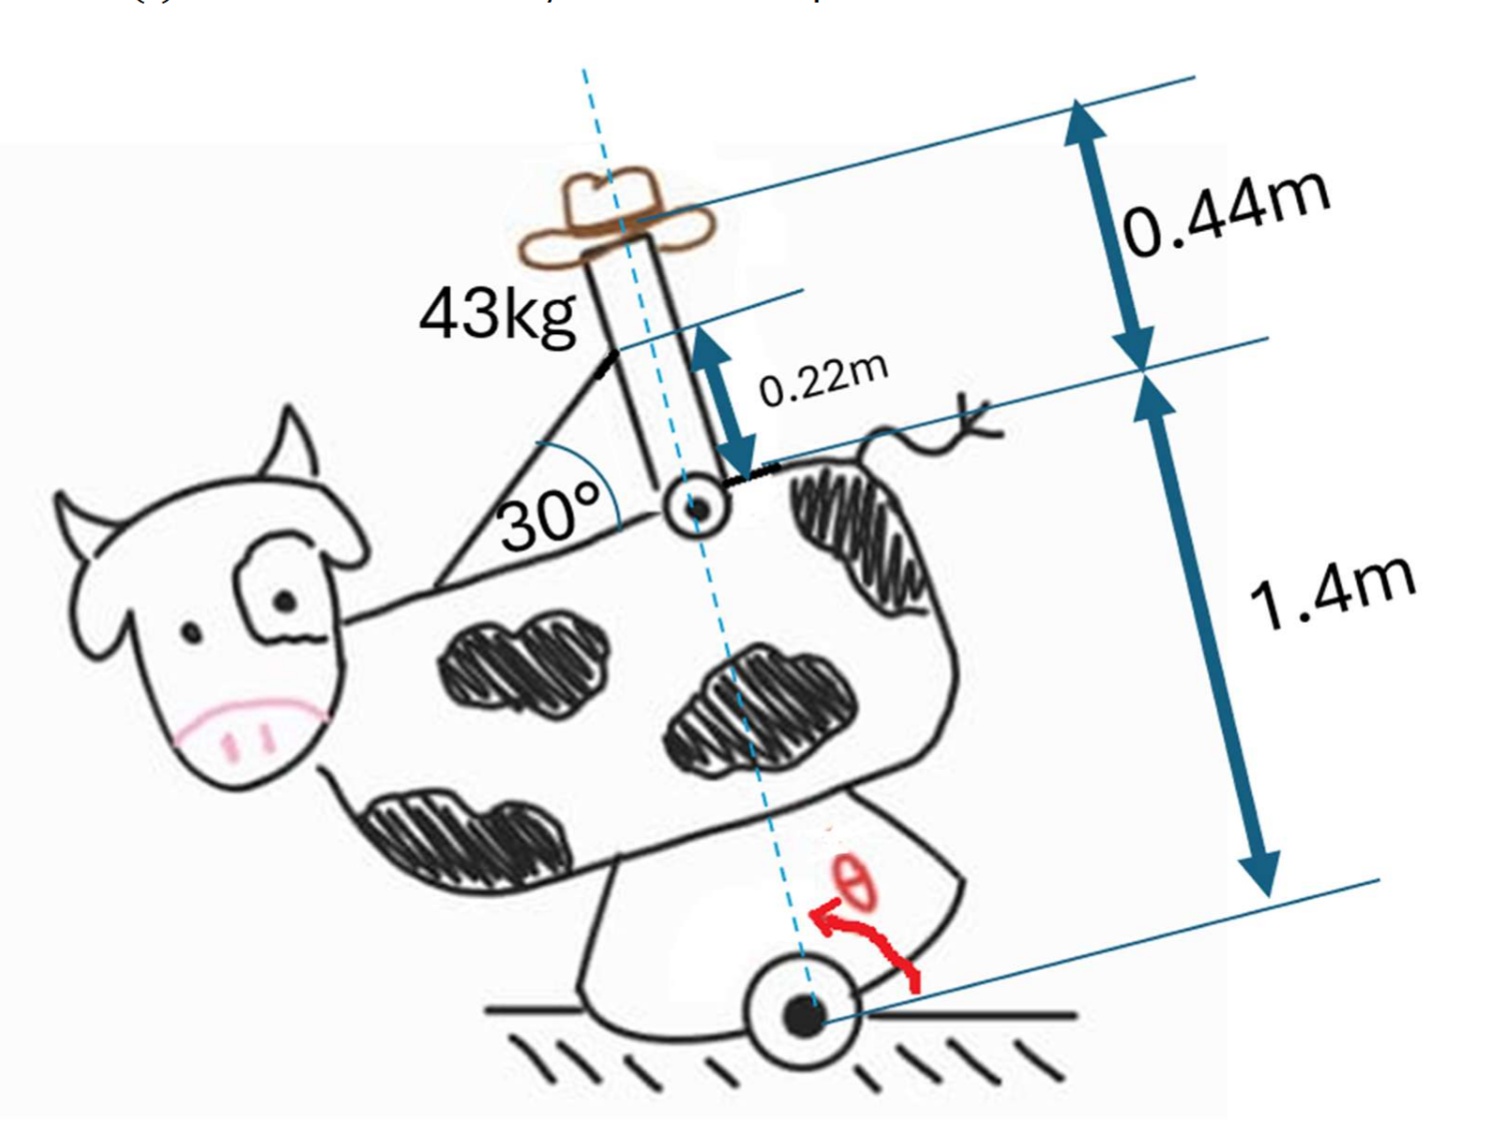

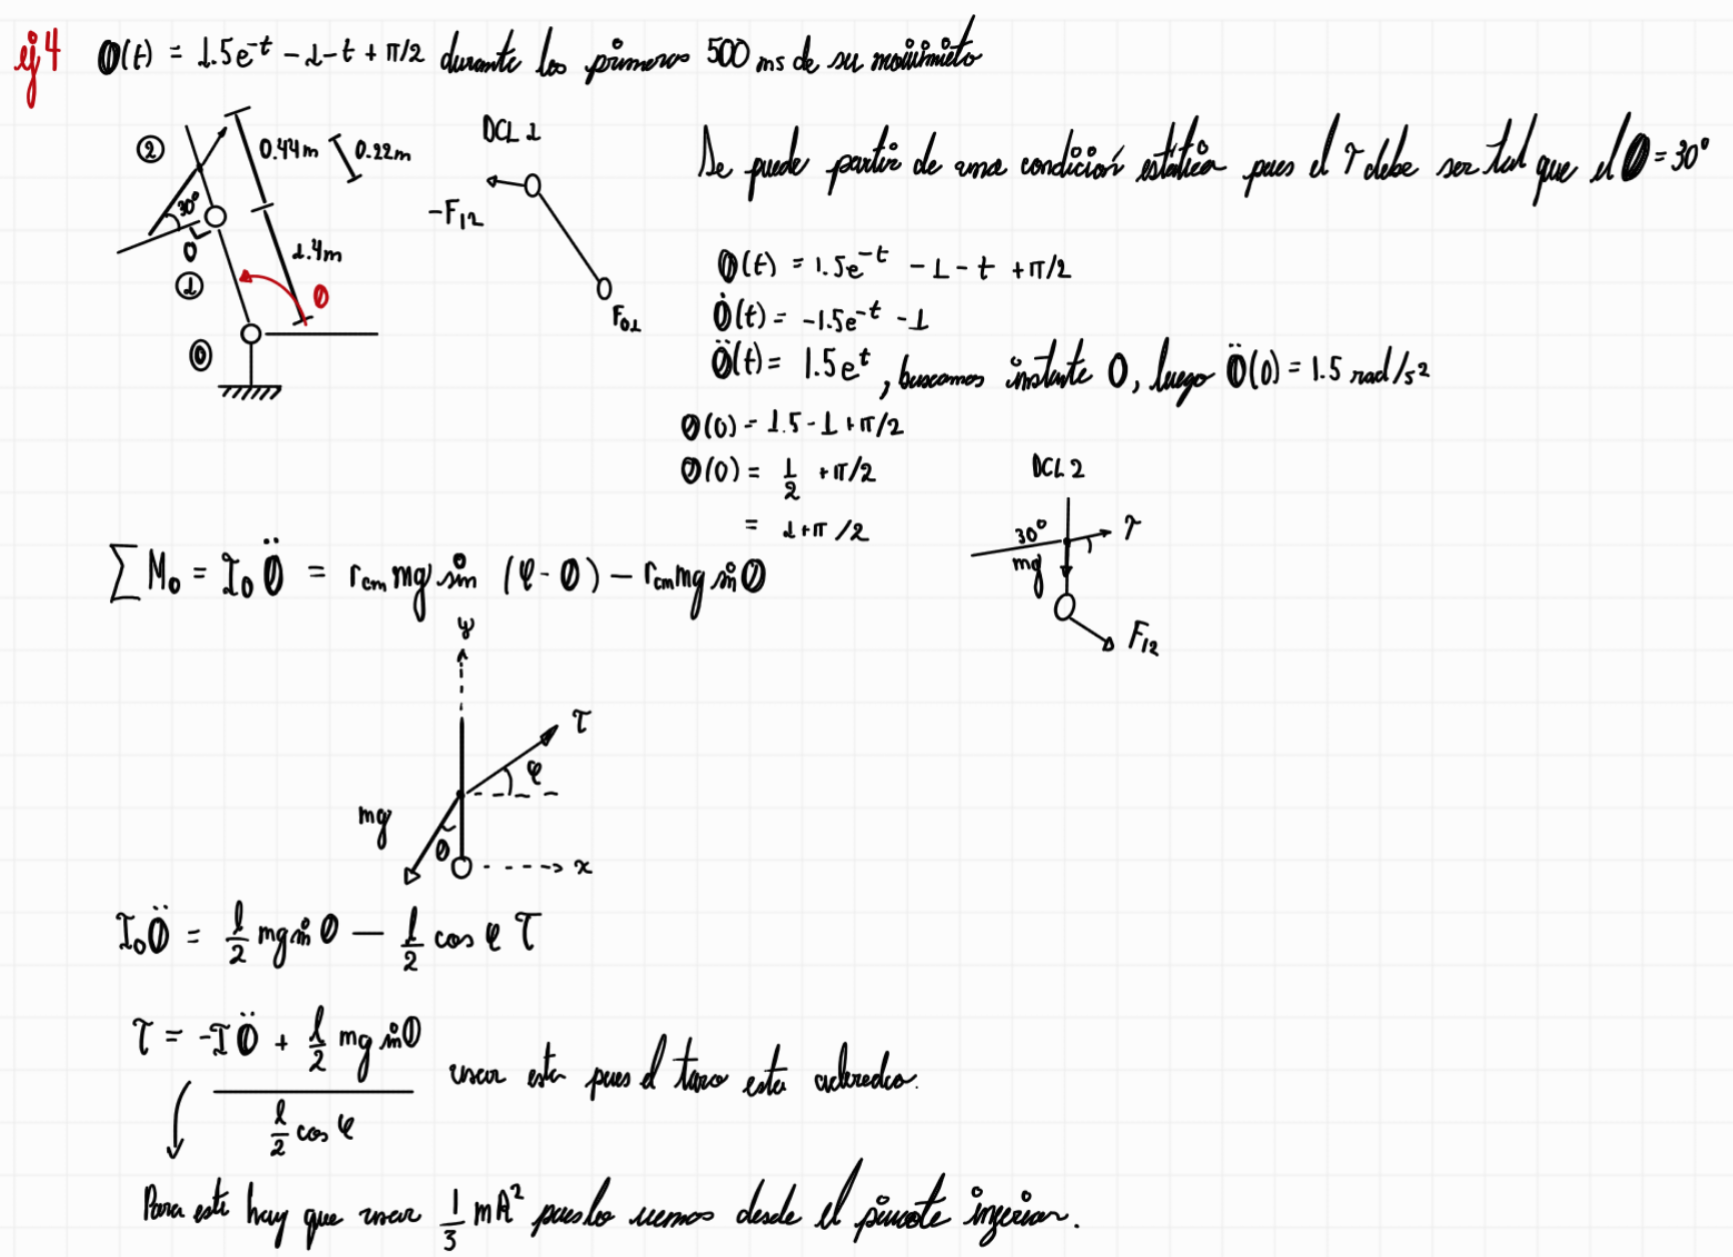

In [95]:


# --- Parámetros físicos ---
r_val   = 0.44             # longitud del jinete (brazo del pivote a la mano) [m]
rcm_val = 0.22             # distancia al centro de masa del jinete [m]
gamma_val = deg2rad(30)    # ángulo de la cuerda respecto al toro [rad]
m_val   = 43               # masa del jinete [kg]
g_val   = 9.81             # gravedad [m/s^2]

# --- Definición simbólica del movimiento angular del toro ---
t = symbols('t', real=True)
theta_t = 1.5*exp(t) - 1.5 - t + pi/2    # θ(t)
theta_ddot = theta_t.diff(t, 2)           # aceleración angular

# --- Evaluación en el instante inicial (t = 0 s) ---
theta_val = float(theta_t.subs(t, 0))
theta_dd_val = float(theta_ddot.subs(t, 0))   # = 1.5 rad/s²

# --- Cálculo del momento de inercia respecto al pivote (extremo de la barra) ---
#     I = (1/3) m L^2  , donde L = 2*rcm
L_val = 2 * rcm_val
I_val = (1/3) * m_val * L_val**2

# --- Ecuación de momentos respecto al eje de giro ---
#     I*θ¨ = T*r*sin(γ + θ) - m*g*rcm*cos(θ)
T = symbols('T', real=True)
Momentos = Eq(I_val*theta_dd_val, T*r_val*sin(gamma_val + theta_val) - m_val*g_val*rcm_val*cos(theta_val))

# --- Despeje simbólico ---
T_sol = solve(Momentos, T)[0]

# --- Valor numérico ---
T_val = float(T_sol.evalf())

# --- Impresión de resultados ---
print(f"Ángulo instantáneo θ(0) = {theta_val:.3f} rad")
print(f"Aceleración angular θ¨(0) = {theta_dd_val:.3f} rad/s²")
print(f"Tensión en la cuerda: T = {T_val:.3f} N")


Ángulo instantáneo θ(0) = 1.571 rad
Aceleración angular θ¨(0) = 1.500 rad/s²
Tensión en la cuerda: T = 10.923 N


## ej4 bono

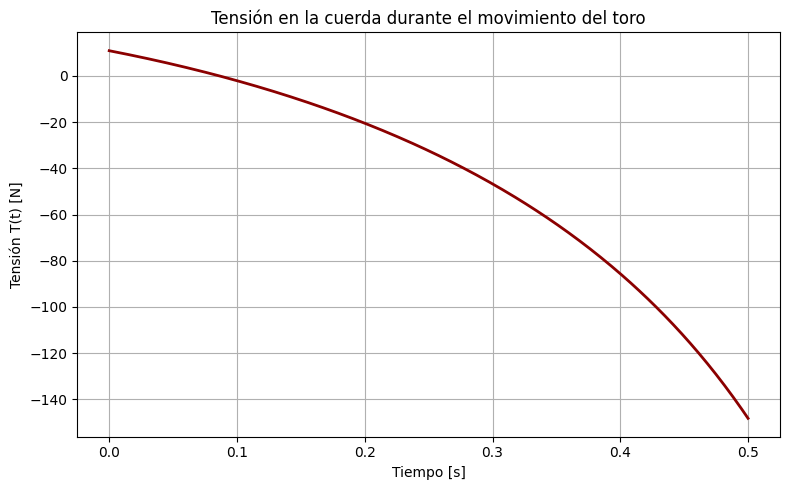

Tensión inicial T(0) = 10.923 N
Tensión final T(0.5s) = -148.230 N


In [96]:
# --- Parámetros físicos ---
r_val   = 0.44             # longitud del jinete (del pivote a la mano) [m]
rcm_val = 0.22             # distancia al centro de masa del jinete [m]
gamma_val = deg2rad(30)    # ángulo de la cuerda respecto al toro [rad]
m_val   = 43               # masa del jinete [kg]
g_val   = 9.81             # gravedad [m/s^2]

# --- Definición simbólica del movimiento del toro ---
t = symbols('t', real=True)
theta_t = 1.5*exp(t) - 1.5 - t + pi/2      # θ(t)
theta_ddot = theta_t.diff(t, 2)             # aceleración angular θ¨(t)

# --- Momento de inercia del jinete respecto al pivote ---
L_val = 2 * rcm_val
I_val = (1/3) * m_val * L_val**2

# --- Definición simbólica de la ecuación de momentos ---
# I*θ¨ = T*r*sin(γ + θ) - m*g*rcm*cos(θ)
T = symbols('T', real=True)
Momentos = Eq(I_val*theta_ddot, T*r_val*sin(gamma_val + theta_t) - m_val*g_val*rcm_val*cos(theta_t))

# --- Despeje simbólico de T(t) ---
T_expr = solve(Momentos, T)[0]

# --- Evaluación numérica de T(t) en el intervalo 0 → 0.5 s ---
t_vals = np.linspace(0, 0.5, 300)
T_vals = [float(T_expr.subs(t, tt)) for tt in t_vals]

# --------------------------------------------------------------
# Gráfica de la tensión durante el recorrido
# --------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(t_vals, T_vals, color='darkred', lw=2)
plt.title("Tensión en la cuerda durante el movimiento del toro")
plt.xlabel("Tiempo [s]")
plt.ylabel("Tensión T(t) [N]")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Valor inicial y final para referencia ---
print(f"Tensión inicial T(0) = {T_vals[0]:.3f} N")
print(f"Tensión final T(0.5s) = {T_vals[-1]:.3f} N")


# Análisis de resultados

Segun los resultados yo no creo que el torso de nuestro ingeniero o ingeniera mecánica pueda sostenerse únicamente con la fuerza de la cuerda, pues vamos a darnos cuanta rápidamente que vamos a necesitar una tensión negativa para hacer esto. De hecho esto es algo que cualquiera que se haya montando en un toro mecánico sabe porque a medida que el toro avanza hacia adelante vamos a poder requerir cada vez menos de la cuerda y a empezar a irnos para adelante. En conclusión, no, no se puede sostenerse únicamente de la cuerda.